# Notebook 07 — Location Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Analyse ride volumes, performance, revenue, and directional flows by location and zone.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/07_*`, tables in `outputs/reports/`  

> Zone mapping is based on manual inspection of all 176 location names — methodology documented in
> `PROJECT_PLAN.md §2 Stage 2`. Unmapped locations are labelled 'Unknown'.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 7.1 Location Volume

In [2]:
top_pickup = df['Pickup Location'].value_counts().head(20)
top_drop   = df['Drop Location'].value_counts().head(20)
top_routes = df['route'].value_counts().head(20)

print('Top 10 Pickup Locations:'); print(top_pickup.head(10).to_string())
print(); print('Top 10 Drop Locations:');   print(top_drop.head(10).to_string())
print(); print('Top 10 Routes:');            print(top_routes.head(10).to_string())

Top 10 Pickup Locations:
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907

Top 10 Drop Locations:
Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902

Top 10 Routes:
route
DLF City Court → Bhiwadi           17
Akshardham → RK Puram              16
Janakpuri → Faridabad Sector 15    16
Ghaziabad → Badshahpur             15
Rithala → Udyog Vihar Phase 4      15
Jor Bagh → Rohini East             15
Vatika Chowk → Rithala             15
Subhash Nagar → Basai Dhankot      14
Rohini West → Sohna Road           14
Chirag Delhi → Noida Film City     14


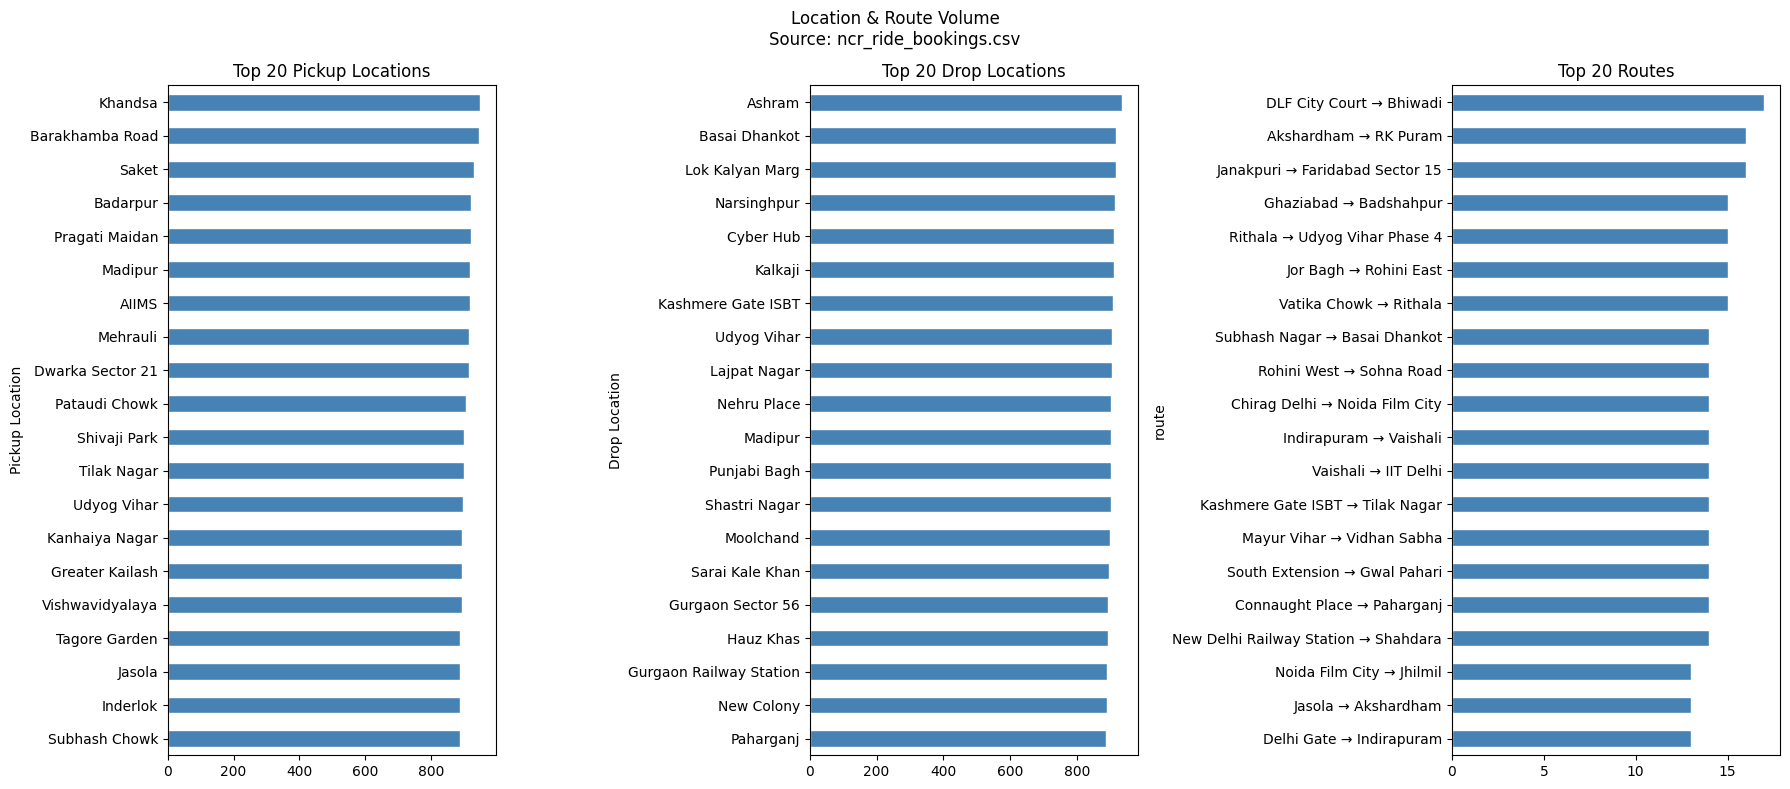

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, data, title in zip(axes,
        [top_pickup, top_drop, top_routes],
        ['Top 20 Pickup Locations', 'Top 20 Drop Locations', 'Top 20 Routes']):
    data.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title); ax.invert_yaxis()
fig.suptitle('Location & Route Volume\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/07_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
zone_vol = df['pickup_zone'].value_counts()
print('Ride Volume by Pickup Zone:'); print(zone_vol.to_string())
unknown_pct = zone_vol.get('Unknown', 0) / len(df) * 100
print(f'  Unknown zone: {unknown_pct:.2f}% of rides')

Ride Volume by Pickup Zone:
pickup_zone
Delhi Core            32508
Delhi South           22140
Delhi North           19809
Gurgaon               16892
Delhi West            16347
Delhi East            15065
Gurgaon Peripheral    12878
Noida                  8495
Outer NCR              5035
Faridabad               831
  Unknown zone: 0.00% of rides


## 7.2 Location Performance

In [5]:
loc_perf = df.groupby('Pickup Location').agg(
    total_rides=('Booking ID', 'count'),
    completed=('is_completed', 'sum'),
    avg_booking_value=('Booking Value', 'mean'),
    avg_vtat=('Avg VTAT', 'mean'),
    ndf_count=('Booking Status', lambda s: (s == 'No Driver Found').sum()),
).round(2)
loc_perf['completion_rate_pct'] = (loc_perf['completed'] / loc_perf['total_rides'] * 100).round(1)
loc_perf['ndf_rate_pct'] = (loc_perf['ndf_count'] / loc_perf['total_rides'] * 100).round(1)
loc_perf = loc_perf.sort_values('total_rides', ascending=False)
loc_perf.to_csv('outputs/reports/location_performance.csv')
print('Top 15 Pickup Locations by Volume:')
print(loc_perf.head(15)[['total_rides','completion_rate_pct','avg_booking_value','avg_vtat','ndf_rate_pct']].to_string())
print('Saved: outputs/reports/location_performance.csv')

Top 15 Pickup Locations by Volume:
                  total_rides  completion_rate_pct  avg_booking_value  avg_vtat  ndf_rate_pct
Pickup Location                                                                              
Khandsa                   949                 63.2             511.33      8.38           6.4
Barakhamba Road           946                 62.8             518.47      8.45           6.1
Saket                     931                 59.8             474.02      8.60           7.0
Badarpur                  921                 61.6             521.01      8.74           6.7
Pragati Maidan            920                 58.5             503.84      8.36           7.6
Madipur                   919                 63.0             497.26      8.31           6.9
AIIMS                     918                 61.2             526.22      8.28           6.9
Mehrauli                  915                 62.7             484.95      8.24           7.8
Dwarka Sector 21         

In [6]:
# Worst supply locations: highest NDF rate (min 100 rides)
worst_supply = loc_perf[loc_perf['total_rides'] >= 100].nlargest(10, 'ndf_rate_pct')
print('Top 10 Pickup Locations by NDF Rate (min 100 bookings):')
print(worst_supply[['total_rides','ndf_rate_pct','avg_vtat']].to_string())

Top 10 Pickup Locations by NDF Rate (min 100 bookings):
                 total_rides  ndf_rate_pct  avg_vtat
Pickup Location                                     
Old Gurgaon              807          10.3      8.60
Paharganj                825           9.6      8.55
Vinobapuri               823           9.2      8.38
Rohini West              835           9.0      8.23
Greater Noida            866           8.9      8.44
Pataudi Chowk            907           8.8      8.50
Dwarka Mor               840           8.6      8.48
Arjangarh                810           8.6      8.56
Pitampura                851           8.5      8.39
Udyog Bhawan             838           8.5      8.49


## 7.3 Directional Flow (Zone-to-Zone)

In [7]:
zone_flow = df.groupby(['pickup_zone','drop_zone']).size().unstack(fill_value=0)
print('Zone-to-Zone Ride Volume:')
print(zone_flow.to_string())
zone_flow.to_csv('outputs/reports/zone_flow.csv')

# Intra vs inter zone
intra = sum(zone_flow.loc[z, z] for z in zone_flow.index if z in zone_flow.columns)
total_rides = len(df)
print(f'\nIntra-zone rides: {intra:,}  ({intra/total_rides*100:.1f}%)')
print(f'Inter-zone rides: {total_rides-intra:,}  ({(total_rides-intra)/total_rides*100:.1f}%)')

Zone-to-Zone Ride Volume:
drop_zone           Delhi Core  Delhi East  Delhi North  Delhi South  Delhi West  Faridabad  Gurgaon  Gurgaon Peripheral  Noida  Outer NCR
pickup_zone                                                                                                                               
Delhi Core                6842        3305         4270         4854        3492        182     3759                2859   1829       1116
Delhi East                3393        1429         1993         2177        1650         86     1722                1291    840        484
Delhi North               4249        2067         2485         2892        2186        106     2255                1695   1190        684
Delhi South               4922        2231         2949         3140        2371        137     2468                1862   1283        777
Delhi West                3691        1695         2111         2338        1720         99     1874                1369    912        538
F

## 7.4 Revenue by Location (GBV)

Top 15 Pickup Locations by GBV:
Pickup Location
Barakhamba Road     ₹309,713
Khandsa             ₹309,041
Pataudi Chowk       ₹306,774
Tughlakabad         ₹299,419
Subhash Chowk       ₹299,023
Badarpur            ₹298,309
Inderlok            ₹296,487
AIIMS               ₹296,028
ITO                 ₹292,168
Saidulajab          ₹291,251
Udyog Vihar         ₹291,078
Jama Masjid         ₹290,846
Botanical Garden    ₹290,768
IMT Manesar         ₹289,913
Greater Noida       ₹289,735


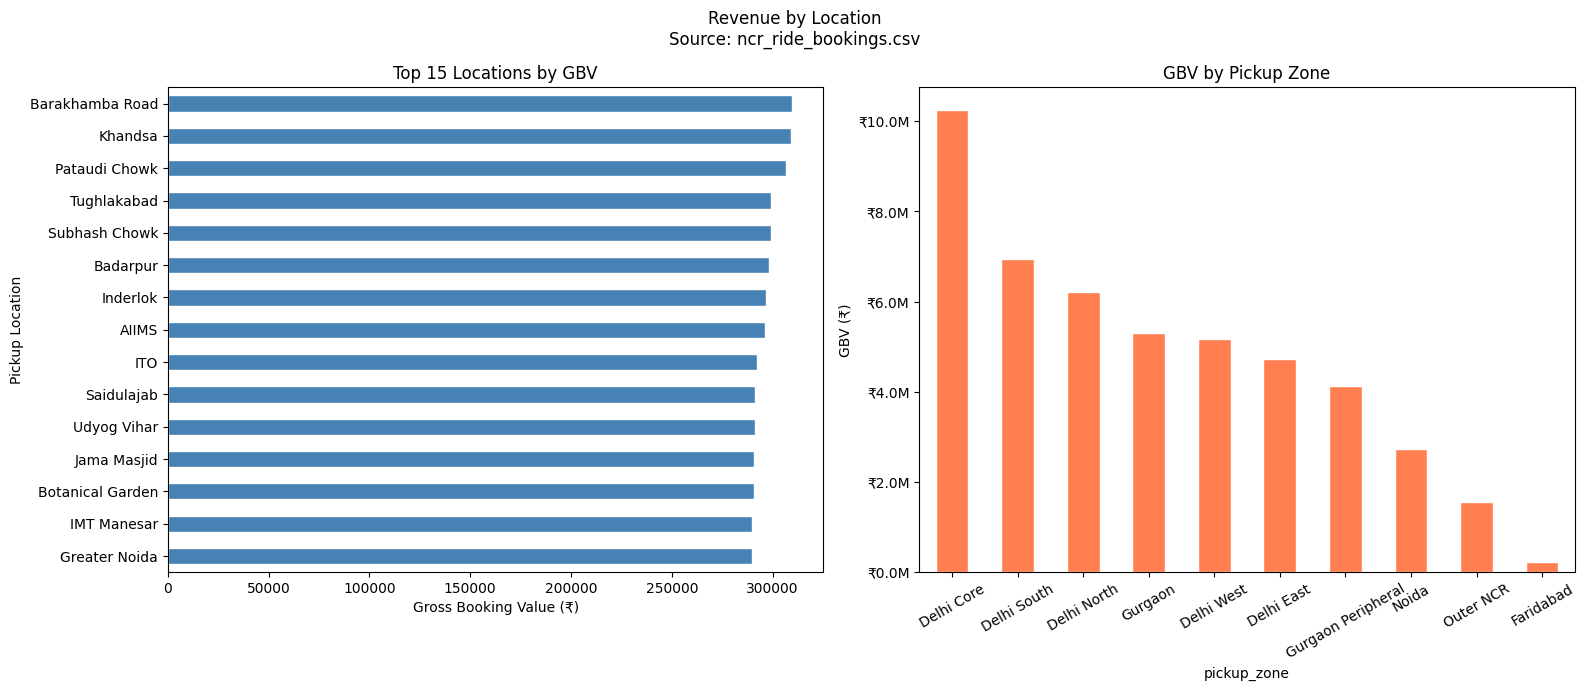

In [8]:
loc_gbv = completed.groupby('Pickup Location')['Booking Value'].sum().sort_values(ascending=False)
loc_fpk = completed.groupby('Pickup Location')['fare_per_km'].mean().sort_values(ascending=False)

print('Top 15 Pickup Locations by GBV:')
print(loc_gbv.head(15).apply(lambda x: f'₹{x:,.0f}').to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
loc_gbv.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Locations by GBV'); axes[0].set_xlabel('Gross Booking Value (₹)')
zone_gbv = completed.groupby('pickup_zone')['Booking Value'].sum().sort_values(ascending=False)
zone_gbv.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('GBV by Pickup Zone'); axes[1].set_ylabel('GBV (₹)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
fig.suptitle('Revenue by Location\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/07_location_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- Net revenue per location cannot be calculated (no cost data).
- Zone mapping covers all 176 locations — 'Unknown' entries are flagged but not force-assigned.